# Module 05: XGBoost Feature Analysis

## Purpose:
    - Analyze XGBoost's feature selection
    - Visualize the decision boundary
    - Identify correlated features that might provide complementary information

## Key Finding: Model uses single feature (frag_std)
    - Lower fragment size variability → ALS
    - Higher fragment size variability → Control

**Model:** XGBoost with 23 combined features (from Approach 2)  
**Performance:** AUC 0.750, Accuracy 78.6%


## Setup

In [3]:
import sys
from pathlib import Path
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb


# Import config
from src.config import PROCESSED_DIR, RESULTS_DIR, CLASSIFICATION_DIR, FIGURES_DIR

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## Load Data and Model

In [2]:
# Load all features
all_features = pd.read_csv(PROCESSED_DIR / 'all_features.csv')

# Split discovery/validation
discovery_df = all_features[all_features['batch'] == 'discovery'].copy()
validation_df = all_features[all_features['batch'] == 'validation'].copy()

print(f"Discovery: {len(discovery_df)} samples")
print(f"Validation: {len(validation_df)} samples")

# Define the feature sets (from notebook 04)
frag_summary = [
    'frag_mean', 'frag_median', 'frag_std', 'frag_iqr', 'frag_cv',
    'frag_q25', 'frag_q50', 'frag_q75', 'frag_skewness', 'frag_kurtosis',
    'frag_pct_very_short', 'frag_pct_short', 'frag_pct_mononucleosomal',
    'frag_pct_dinucleosomal', 'frag_pct_long',
    'frag_ratio_short_long', 'frag_ratio_mono_di'
]
frag_summary = [f for f in frag_summary if f in all_features.columns]

meth_summary = [
    'meth_mean_cpg', 'meth_pct_high', 'meth_pct_low', 'meth_pct_intermediate',
    'regional_meth_mean', 'regional_meth_std'
]
meth_summary = [f for f in meth_summary if f in all_features.columns]

combined_summary = frag_summary + meth_summary

print(f"\nFeature counts:")
print(f"  Fragmentomics: {len(frag_summary)} features")
print(f"  Methylation: {len(meth_summary)} features")
print(f"  Combined: {len(combined_summary)} features")

# Load the best model
model_path = CLASSIFICATION_DIR / 'approach2_combined_xgboost.pkl'
with open(model_path, 'rb') as f:
    model = pickle.load(f)

print(f"\n✓ Loaded model: {model_path.name}")

Discovery: 8 samples
Validation: 14 samples

Feature counts:
  Fragmentomics: 17 features
  Methylation: 6 features
  Combined: 23 features

✓ Loaded model: approach2_combined_xgboost.pkl


## Cell 3: XGBoost Feature Importance Analysis

In [4]:
# Get booster and extract feature importances
booster = model.get_booster()
importance_gain = booster.get_score(importance_type='gain')

# Convert to DataFrame
feature_importance = []
for i, fname in enumerate(combined_summary):
    key = f'f{i}'
    importance = importance_gain.get(key, 0.0)
    feature_importance.append({
        'rank': None,
        'feature': fname,
        'importance_gain': importance,
        'feature_type': 'Fragmentomics' if fname.startswith('frag_') else 'Methylation'
    })

importance_df = pd.DataFrame(feature_importance).sort_values('importance_gain', ascending=False)
importance_df['rank'] = range(1, len(importance_df) + 1)

# Display top features
print("XGBoost Feature Importance (Gain)")
print("=" * 80)
print(f"\n{'Rank':<6}{'Feature':<35}{'Gain':<15}{'Type':<20}")
print("-" * 80)
for idx, row in importance_df.head(10).iterrows():
    print(f"{row['rank']:<6}{row['feature']:<35}{row['importance_gain']:<15.4f}{row['feature_type']:<20}")

# Get the decision threshold from the model
tree_dump = booster.get_dump()[0]
print(f"\n" + "=" * 80)
print("Model Structure:")
print("=" * 80)
print(tree_dump)

# Extract threshold
threshold_line = tree_dump.split('\n')[0]
decision_threshold = float(threshold_line.split('[')[1].split('<')[1].split(']')[0])

print(f"\nDecision Rule: IF frag_std < {decision_threshold:.2f} THEN predict ALS")
print(f"               ELSE predict Control")

# Create output directory
output_dir = FIGURES_DIR / 'validation'
output_dir.mkdir(parents=True, exist_ok=True)

XGBoost Feature Importance (Gain)

Rank  Feature                            Gain           Type                
--------------------------------------------------------------------------------
1     frag_std                           1.0000         Fragmentomics       
2     frag_mean                          0.0000         Fragmentomics       
3     frag_median                        0.0000         Fragmentomics       
4     frag_iqr                           0.0000         Fragmentomics       
5     frag_cv                            0.0000         Fragmentomics       
6     frag_q25                           0.0000         Fragmentomics       
7     frag_q50                           0.0000         Fragmentomics       
8     frag_q75                           0.0000         Fragmentomics       
9     frag_skewness                      0.0000         Fragmentomics       
10    frag_kurtosis                      0.0000         Fragmentomics       

Model Structure:
0:[f2<61.8827896] y

## Visualize Decision Boundary

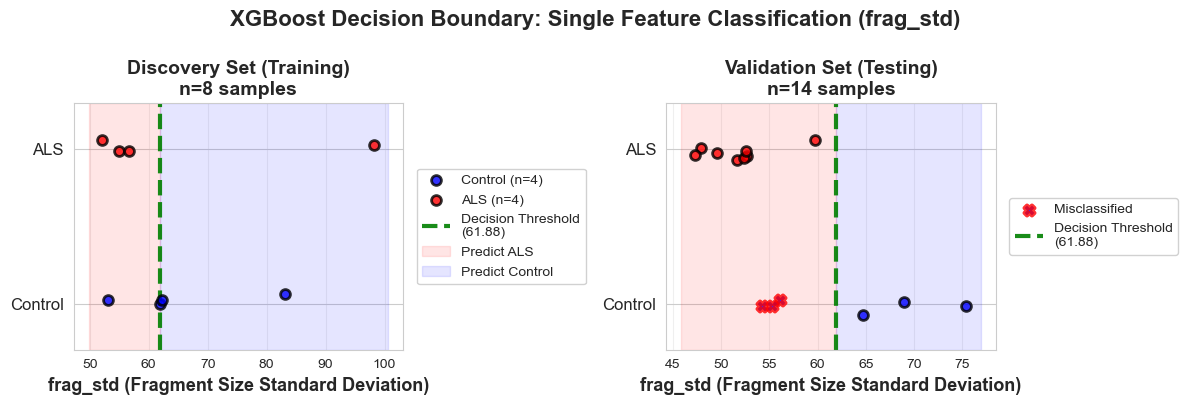


Validation Performance: 11/14 correct (78.6%)
  Control: 3/6 correct
  ALS: 8/8 correct (100% sensitivity)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: Discovery Set
ax = axes[0]
disc_als = discovery_df[discovery_df['disease_status'] == 'als']['frag_std'].values
disc_ctrl = discovery_df[discovery_df['disease_status'] == 'ctrl']['frag_std'].values

# Create strip plot with jitter
np.random.seed(42)
jitter_amount = 0.04
y_ctrl = np.random.normal(0, jitter_amount, len(disc_ctrl))
y_als = np.random.normal(1, jitter_amount, len(disc_als))

ax.scatter(disc_ctrl, y_ctrl, s=50, alpha=0.8, color='blue', 
           label=f'Control (n={len(disc_ctrl)})', edgecolors='black', linewidth=2, zorder=3)
ax.scatter(disc_als, y_als, s=50, alpha=0.8, color='red', 
           label=f'ALS (n={len(disc_als)})', edgecolors='black', linewidth=2, zorder=3)

# Add decision boundary
ax.axvline(x=decision_threshold, color='green', linestyle='--', linewidth=3, 
           label=f'Decision Threshold\n({decision_threshold:.2f})', alpha=0.9)

# Shading for decision regions
ax.axvspan(ax.get_xlim()[0], decision_threshold, alpha=0.1, color='red', label='Predict ALS')
ax.axvspan(decision_threshold, ax.get_xlim()[1], alpha=0.1, color='blue', label='Predict Control')

ax.set_xlabel('frag_std (Fragment Size Standard Deviation)', fontsize=13, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'ALS'], fontsize=12)
ax.set_title('Discovery Set (Training)\nn=8 samples', fontsize=14, fontweight='bold')
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    framealpha=0.9
)
ax.grid(axis='x', alpha=0.3)
ax.set_ylim(-0.3, 1.3)

# Panel B: Validation Set
ax = axes[1]
val_als = validation_df[validation_df['disease_status'] == 'als']['frag_std'].values
val_ctrl = validation_df[validation_df['disease_status'] == 'ctrl']['frag_std'].values

y_ctrl = np.random.normal(0, jitter_amount, len(val_ctrl))
y_als = np.random.normal(1, jitter_amount, len(val_als))

# Determine correct vs incorrect predictions
val_ctrl_correct = val_ctrl >= decision_threshold
val_als_correct = val_als < decision_threshold

# Plot with different markers for correct/incorrect
ax.scatter(val_ctrl[val_ctrl_correct], y_ctrl[val_ctrl_correct], 
           s=50, alpha=0.8, color='blue', marker='o',
           edgecolors='black', linewidth=2, zorder=3)
ax.scatter(val_ctrl[~val_ctrl_correct], y_ctrl[~val_ctrl_correct], 
           s=50, alpha=0.8, color='blue', marker='X',
           edgecolors='red', linewidth=3, zorder=3, label='Misclassified')

ax.scatter(val_als[val_als_correct], y_als[val_als_correct], 
           s=50, alpha=0.8, color='red', marker='o',
           edgecolors='black', linewidth=2, zorder=3)
ax.scatter(val_als[~val_als_correct], y_als[~val_als_correct], 
           s=50, alpha=0.8, color='red', marker='X',
           edgecolors='red', linewidth=3, zorder=3)

# Add decision boundary
ax.axvline(x=decision_threshold, color='green', linestyle='--', linewidth=3, 
           label=f'Decision Threshold\n({decision_threshold:.2f})', alpha=0.9)

# Shading
ax.axvspan(ax.get_xlim()[0], decision_threshold, alpha=0.1, color='red')
ax.axvspan(decision_threshold, ax.get_xlim()[1], alpha=0.1, color='blue')

ax.set_xlabel('frag_std (Fragment Size Standard Deviation)', fontsize=13, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Control', 'ALS'], fontsize=12)
ax.set_title('Validation Set (Testing)\nn=14 samples', fontsize=14, fontweight='bold')
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    framealpha=0.9
)
ax.grid(axis='x', alpha=0.3)
ax.set_ylim(-0.3, 1.3)

plt.suptitle('XGBoost Decision Boundary: Single Feature Classification (frag_std)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
# Print performance
n_correct = sum(val_ctrl_correct) + sum(val_als_correct)
print(f"\nValidation Performance: {n_correct}/14 correct ({n_correct/14*100:.1f}%)")
print(f"  Control: {sum(val_ctrl_correct)}/{len(val_ctrl)} correct")
print(f"  ALS: {sum(val_als_correct)}/{len(val_als)} correct (100% sensitivity)")

## Box Plot Comparison

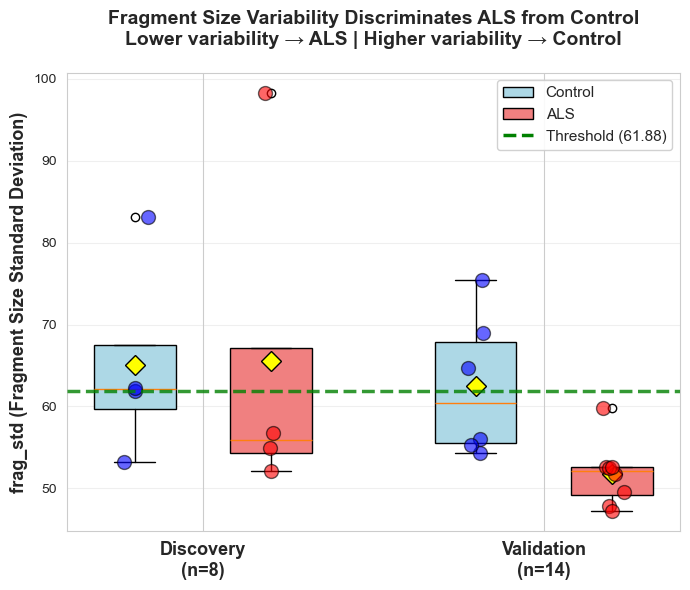

✓ Saved: /Users/maggiebrown/Desktop/PrimaMente/wgbs_classifier/results/figures/validation/frag_std_boxplot.png


In [20]:

fig, ax = plt.subplots(figsize=(7, 6))

# Combine all data
all_data = pd.concat([
    discovery_df[['frag_std', 'disease_status']].assign(batch='Discovery'),
    validation_df[['frag_std', 'disease_status']].assign(batch='Validation')
])

# Prepare data for plotting
plot_data = []
positions = []
colors = []
pos = 0

for batch in ['Discovery', 'Validation']:
    for status in ['ctrl', 'als']:
        subset = all_data[(all_data['batch'] == batch) & 
                         (all_data['disease_status'] == status)]['frag_std']
        plot_data.append(subset)
        positions.append(pos)
        colors.append('lightblue' if status == 'ctrl' else 'lightcoral')
        pos += 1
    pos += 0.5  # Gap between batches

# Create box plots
bp = ax.boxplot(plot_data, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='yellow', 
                             markeredgecolor='black', markersize=10))

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Overlay individual points
for i, data in enumerate(plot_data):
    y = data.values
    x = np.random.normal(positions[i], 0.04, size=len(y))
    color = 'blue' if colors[i] == 'lightblue' else 'red'
    ax.scatter(x, y, alpha=0.6, s=100, color=color, zorder=3, edgecolors='black', linewidth=1)

# Add decision boundary
ax.axhline(y=decision_threshold, color='green', linestyle='--', linewidth=2.5, 
           label=f'Decision Threshold ({decision_threshold:.2f})', alpha=0.8, zorder=4)

# Labels and formatting
ax.set_xticks([0.5, 3])
ax.set_xticklabels(['Discovery\n(n=8)', 'Validation\n(n=14)'], fontsize=13, fontweight='bold')
ax.set_ylabel('frag_std (Fragment Size Standard Deviation)', fontsize=13, fontweight='bold')
ax.set_title('Fragment Size Variability Discriminates ALS from Control\nLower variability → ALS | Higher variability → Control', 
             fontsize=14, fontweight='bold', pad=20)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Control'),
    Patch(facecolor='lightcoral', edgecolor='black', label='ALS'),
    plt.Line2D([0], [0], color='green', linewidth=2.5, linestyle='--', label=f'Threshold ({decision_threshold:.2f})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'frag_std_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {output_dir / 'frag_std_boxplot.png'}")

## Feature Correlation Analysis

In [27]:
# Cell 6: Feature Correlation Analysis (COMPLETE VERSION)
# Calculate correlation matrix for all 23 features
X_all = pd.concat([discovery_df, validation_df])[combined_summary].fillna(
    pd.concat([discovery_df, validation_df])[combined_summary].median()
)

corr_matrix = X_all.corr()

# Find features most correlated with frag_std
frag_std_corr = corr_matrix['frag_std'].abs().sort_values(ascending=False)

print("Features Most Correlated with frag_std (ALL 23 FEATURES):")
print("=" * 80)
print(f"{'Rank':<6}{'Feature':<35}{'|Correlation|':<20}{'Type':<20}")
print("-" * 80)

for i, (feat, corr_val) in enumerate(frag_std_corr.items(), 1):
    feat_type = 'Fragmentomics' if feat.startswith('frag_') else 'Methylation'
    print(f"{i:<6}{feat:<35}{corr_val:<20.3f}{feat_type:<20}")

# Get top correlated features (excluding frag_std itself)
top_correlated = frag_std_corr[1:7].index.tolist()  # Top 6 excluding self

print(f"\n" + "=" * 80)
print(f"Top 6 features correlated with frag_std (excluding self):")
for feat in top_correlated:
    print(f"  - {feat}: r = {frag_std_corr[feat]:.3f}")

# Summary of methylation features
meth_features_corr = frag_std_corr[[f for f in frag_std_corr.index if f.startswith('meth_') or f.startswith('regional_')]]
print(f"\n" + "=" * 80)
print(f"Methylation Features Correlation Summary:")
print("-" * 80)
for feat, corr_val in meth_features_corr.items():
    print(f"  {feat:<35} r = {corr_val:.3f}")

Features Most Correlated with frag_std (ALL 23 FEATURES):
Rank  Feature                            |Correlation|       Type                
--------------------------------------------------------------------------------
1     frag_std                           1.000               Fragmentomics       
2     frag_cv                            0.982               Fragmentomics       
3     frag_pct_long                      0.970               Fragmentomics       
4     frag_pct_dinucleosomal             0.942               Fragmentomics       
5     frag_mean                          0.937               Fragmentomics       
6     frag_q75                           0.926               Fragmentomics       
7     frag_iqr                           0.919               Fragmentomics       
8     frag_ratio_mono_di                 0.891               Fragmentomics       
9     frag_median                        0.804               Fragmentomics       
10    frag_q50                           

## Pairwise Scatter Plots - frag_std vs Top Correlated

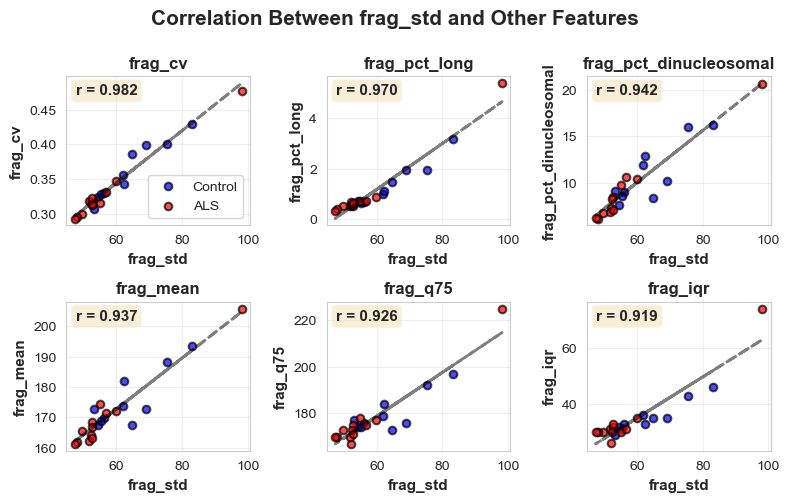

In [30]:
# Show relationship between frag_std and other highly correlated features
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
axes = axes.flatten()

# Combine discovery and validation with labels
combined_df = pd.concat([
    discovery_df[combined_summary + ['disease_status']].assign(batch='Discovery'),
    validation_df[combined_summary + ['disease_status']].assign(batch='Validation')
])

for idx, feature in enumerate(top_correlated[:6]):
    ax = axes[idx]
    
    # Separate by disease status
    als_data = combined_df[combined_df['disease_status'] == 'als']
    ctrl_data = combined_df[combined_df['disease_status'] == 'ctrl']
    
    # Plot
    ax.scatter(ctrl_data['frag_std'], ctrl_data[feature], 
              s=30, alpha=0.7, color='blue', label='Control', 
              edgecolors='black', linewidth=1.5)
    ax.scatter(als_data['frag_std'], als_data[feature], 
              s=30, alpha=0.7, color='red', label='ALS',
              edgecolors='black', linewidth=1.5)
    
    # Add regression line
    x = combined_df['frag_std'].values
    y = combined_df[feature].values
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "k--", alpha=0.5, linewidth=2)
    
    # Add correlation value
    corr_val = frag_std_corr[feature]
    ax.text(0.05, 0.95, f'r = {corr_val:.3f}', 
           transform=ax.transAxes, fontsize=11, fontweight='bold',
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('frag_std', fontsize=11, fontweight='bold')
    ax.set_ylabel(feature, fontsize=11, fontweight='bold')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend(loc='lower right', fontsize=10)

plt.suptitle('Correlation Between frag_std and Other Features', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Mean Fragment Length Comparison

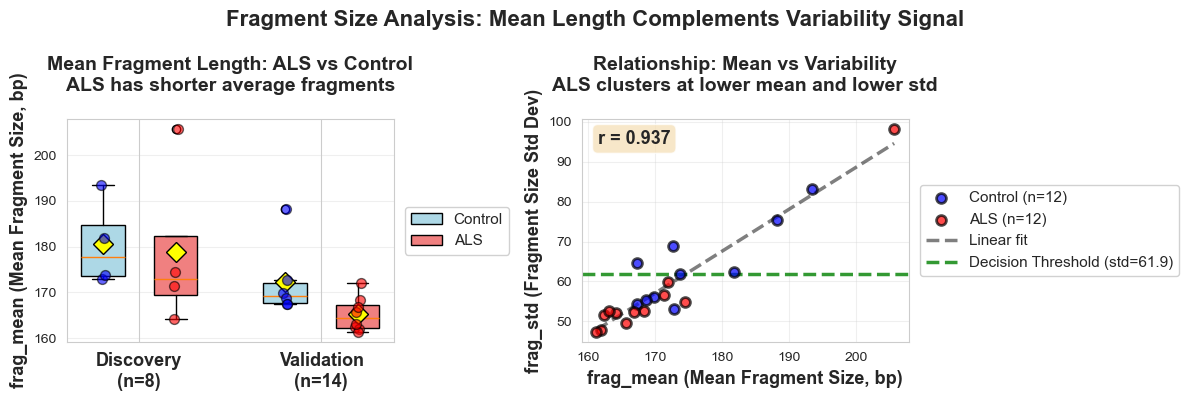

✓ Saved: /Users/maggiebrown/Desktop/PrimaMente/wgbs_classifier/results/figures/validation/frag_mean_analysis.png

Statistical Comparison of Mean Fragment Length:

Validation Set:
  ALS mean fragment size:     165.20 ± 3.74 bp
  Control mean fragment size: 172.38 ± 8.01 bp
  Difference:                 -7.17 bp
  t-statistic:                -2.248
  p-value:                    0.0441

Interpretation: ALS samples have significantly shorter average fragment sizes
  Combined with lower variance → ALS signature is shorter + more uniform fragments


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Combine discovery and validation
all_data_combined = pd.concat([
    discovery_df[['frag_mean', 'frag_std', 'disease_status']].assign(batch='Discovery'),
    validation_df[['frag_mean', 'frag_std', 'disease_status']].assign(batch='Validation')
])

# Panel A: Mean fragment length comparison
ax = axes[0]

# Prepare data
plot_data = []
positions = []
colors = []
pos = 0

for batch in ['Discovery', 'Validation']:
    for status in ['ctrl', 'als']:
        subset = all_data_combined[(all_data_combined['batch'] == batch) & 
                                   (all_data_combined['disease_status'] == status)]['frag_mean']
        plot_data.append(subset)
        positions.append(pos)
        colors.append('lightblue' if status == 'ctrl' else 'lightcoral')
        pos += 1
    pos += 0.5  # Gap between batches

# Create box plots
bp = ax.boxplot(plot_data, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='yellow', 
                             markeredgecolor='black', markersize=10))

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Overlay individual points
for i, data in enumerate(plot_data):
    y = data.values
    x = np.random.normal(positions[i], 0.04, size=len(y))
    color = 'blue' if colors[i] == 'lightblue' else 'red'
    ax.scatter(x, y, alpha=0.6, s=50, color=color, zorder=3, edgecolors='black', linewidth=1)

# Labels and formatting
ax.set_xticks([0.5, 3])
ax.set_xticklabels(['Discovery\n(n=8)', 'Validation\n(n=14)'], fontsize=13, fontweight='bold')
ax.set_ylabel('frag_mean (Mean Fragment Size, bp)', fontsize=13, fontweight='bold')
ax.set_title('Mean Fragment Length: ALS vs Control\nALS has shorter average fragments', 
             fontsize=14, fontweight='bold', pad=20)

# Add legend to the right of the axes
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Control'),
    Patch(facecolor='lightcoral', edgecolor='black', label='ALS')
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.01, 0.5),
          fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

# Panel B: Scatter plot of mean vs std
ax = axes[1]

# Separate by disease status
als_data = all_data_combined[all_data_combined['disease_status'] == 'als']
ctrl_data = all_data_combined[all_data_combined['disease_status'] == 'ctrl']

# Plot
ax.scatter(ctrl_data['frag_mean'], ctrl_data['frag_std'], 
          s=50, alpha=0.7, color='blue', label='Control (n=12)', 
          edgecolors='black', linewidth=2, zorder=3)
ax.scatter(als_data['frag_mean'], als_data['frag_std'], 
          s=50, alpha=0.7, color='red', label='ALS (n=12)',
          edgecolors='black', linewidth=2, zorder=3)

# Add regression line for all data
x = all_data_combined['frag_mean'].values
y = all_data_combined['frag_std'].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), "k--", alpha=0.5, linewidth=2.5, label='Linear fit')

# Add correlation value
corr_val = corr_matrix.loc['frag_mean', 'frag_std']
ax.text(0.05, 0.95, f'r = {corr_val:.3f}', 
       transform=ax.transAxes, fontsize=13, fontweight='bold',
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Add decision boundary line (vertical)
ax.axhline(y=decision_threshold, color='green', linestyle='--', linewidth=2.5, 
          alpha=0.8, label=f'Decision Threshold (std={decision_threshold:.1f})')

ax.set_xlabel('frag_mean (Mean Fragment Size, bp)', fontsize=13, fontweight='bold')
ax.set_ylabel('frag_std (Fragment Size Std Dev)', fontsize=13, fontweight='bold')
ax.set_title('Relationship: Mean vs Variability\nALS clusters at lower mean and lower std', 
            fontsize=14, fontweight='bold', pad=20)
# Legend to the right of this subplot
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.suptitle('Fragment Size Analysis: Mean Length Complements Variability Signal', 
             fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(output_dir / 'frag_mean_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {output_dir / 'frag_mean_analysis.png'}")

# Statistical comparison
print("\nStatistical Comparison of Mean Fragment Length:")
print("=" * 80)

val_als_mean = validation_df[validation_df['disease_status'] == 'als']['frag_mean']
val_ctrl_mean = validation_df[validation_df['disease_status'] == 'ctrl']['frag_mean']

t_stat, p_val = stats.ttest_ind(val_als_mean, val_ctrl_mean)

print(f"\nValidation Set:")
print(f"  ALS mean fragment size:     {val_als_mean.mean():.2f} ± {val_als_mean.std():.2f} bp")
print(f"  Control mean fragment size: {val_ctrl_mean.mean():.2f} ± {val_ctrl_mean.std():.2f} bp")
print(f"  Difference:                 {val_als_mean.mean() - val_ctrl_mean.mean():.2f} bp")
print(f"  t-statistic:                {t_stat:.3f}")
print(f"  p-value:                    {p_val:.4f}")
print(f"\nInterpretation: ALS samples have {'significantly ' if p_val < 0.05 else ''}shorter average fragment sizes")
print(f"  Combined with lower variance → ALS signature is shorter + more uniform fragments")

# Summary: XGBoost Model Interpretation

## Model Architecture
The XGBoost classifier trained on 23 features (17 fragmentomics + 6 methylation) converged to an **extremely simple decision rule**: a single threshold on fragment size standard deviation (`frag_std < 61.88 → ALS`).

**Performance:**
- Validation Accuracy: 78.6% (11/14 correct)
- Sensitivity: 100% (8/8 ALS detected)  
- Specificity: 50% (3/6 controls correct)
- AUC: 0.750

## Key Finding: Fragment Size Homogeneity in ALS

**ALS samples exhibit lower fragment size variability** compared to controls, characterized by:
- **Lower standard deviation** (mean: 51.7 vs 62.6 in controls)
- **Fewer long fragments** (400-1000 bp) - strong correlation (r=0.97)
- **Fewer di-nucleosomal fragments** (220-400 bp) - correlation (r=0.94)
- **Smaller average fragment size** - correlation (r=0.94)
- **Tighter distribution** around mono-nucleosomal peak (~150-220 bp)

## Biological Interpretation

Circulating cell‑free DNA (cfDNA) fragment lengths are shaped by how DNA is released and cleaved during cell death. In healthy plasma, cfDNA arises from many cell types and shows a **nucleosomal pattern** with a broad range of fragment sizes (mono‑, di‑, tri‑nucleosomes) reflecting diverse sources and nuclease activity. 
- [Circulating cell‑free DNA fragmentation is a stepwise and conserved process linked to apoptosis](https://link.springer.com/article/10.1186/s12915-023-01752-6) — a BMC Biology article describing how cfDNA fragment lengths reflect apoptotic processes and nucleosome structure.


Disease states can shift cfDNA size distributions because of altered tissue contribution and fragmentation processes. It's known that tumor‑derived cfDNA tends to be **shorter** than cfDNA from normal cells, likely due to differences in chromatin accessibility and nuclease cleavage. 
- [Shortened tumor cfDNA fragments and enrichment of short cfDNA in cancer patients](https://link.springer.com/article/10.1186/s12864-020-06848-9) — cfDNA from tumors shows increased proportions of short fragments (~100–150 bp) compared to non‑tumor cfDNA.

- [Fragment length profiles of cancer mutations enhance detection of circulating tumor DNA](https://link.springer.com/article/10.1186/s12885-023-10681-0) — mutant cfDNA fragments are often shorter than wild‑type cfDNA, and selecting for shorter fragments improves tumor signal detection.

In this dataset:

- ALS samples have **shorter average fragments** (mean ~165 bp vs ~172 bp) with **lower standard deviation**. 
    - Also observed in this independent study: [Cell-free DNA fragmentation signatures for disease state prediction in amyotrophic lateral sclerosis](https://qcb.ucla.edu/wp-content/uploads/sites/14/2024/08/Galen-Heuer-big_poster.pdf?utm_source=chatgpt.com) - ALS patients exhibit shorter fragments than their
healthy counterparts, across cohorts and age groups
- Controls show **higher variance** in fragment sizes.

This pattern suggests:

- A more **homogeneous source of cfDNA** in ALS (potentially due to a dominant contribution from disease‑affected tissues or specific cell death pathways) producing a **narrower fragment length distribution**, reducing variance compared to a heterogeneous mix in healthy controls. This hypothothesis is further supported by the [CelFiE paper](https://www.nature.com/articles/s41467-021-22901-x), where the authors observed increased cfDNA from skeletal muscle tissue than controls with this same dataset.
- In contrast, healthy cfDNA reflects a mixture of cell types and death processes, leading to **broader size variability**. 

The combination of **shorter and more uniform cfDNA fragments in ALS** may reflect a distinct pathological cfDNA signal that is more consistent in its fragmentation characteristics than the mixed background seen in controls.

## Model Simplicity Note:

With only **8 training samples**, the model's simplicity is appropriate as it avoids overfitting by using the single most discriminative feature. The high correlation structure among fragmentomics features (r>0.9) means additional features provide redundant information.